---
# Data Science for Feature Engineering
## Part 1: A Tour of the Dataset

##### *"In God we trust. All others must bring data."* — W. Edwards Deming

### Director Harold · Lecture Series: Data Science for Feature Engineering

---

Before we build any model, we spend time understanding the data we will use **throughout this entire series**.

This notebook answers four questions:
1. **What do we have?** Tickers, sectors, time range, coverage
2. **What did the market look like?** Cumulative returns, annual performance, correlations
3. **What was the macro environment?** SPY, VIX, yield curve, USD
4. **How much does the market factor explain each stock?** Beta, R², alpha

---

### Dataset (used in every notebook in this series)

| File | Contents |
|---|---|
| `data/ds4fe_panel.parquet` | 50 large-cap US stocks · daily OHLCV · 2010–2024 · 187k rows |
| `data/ds4fe_market.parquet` | SPY · VIX · 10y/3m Treasury yields · USD index · 3,771 rows |
| `data/ds4fe_info.csv` | Sector · company name · market cap per ticker |

If you don't have the data files yet, run `python download_data.py` first.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
from scipy import stats

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

DATA_DIR = 'data'
panel  = pd.read_parquet(f'{DATA_DIR}/ds4fe_panel.parquet')
market = pd.read_parquet(f'{DATA_DIR}/ds4fe_market.parquet')
info   = pd.read_csv(f'{DATA_DIR}/ds4fe_info.csv')

panel['date']  = pd.to_datetime(panel['date'])
market['date'] = pd.to_datetime(market['date'])

ticker_sector = info.set_index('ticker')['sector'].to_dict()
sectors = sorted(info['sector'].dropna().unique())
palette = dict(zip(sectors, plt.cm.tab10.colors[:len(sectors)]))
ticker_order = info.sort_values(['sector','ticker'])['ticker'].tolist()

print(f'panel  : {panel.shape[0]:,} rows | {panel["ticker"].nunique()} tickers | {panel["date"].min().date()} to {panel["date"].max().date()}')
print(f'market : {market.shape[0]:,} rows | cols: {list(market.columns)}')
print(f'info   : {len(info)} tickers')

panel  : 187,247 rows | 50 tickers | 2010-01-05 to 2024-12-30
market : 3,771 rows | cols: ['date', 'spy_close', 'vix', 'yield_10y', 'yield_3m', 'usd_index', 'spy_volume', 'market_ret', 'yield_spread']
info   : 50 tickers


---
## Section 1: What Do We Have?
---

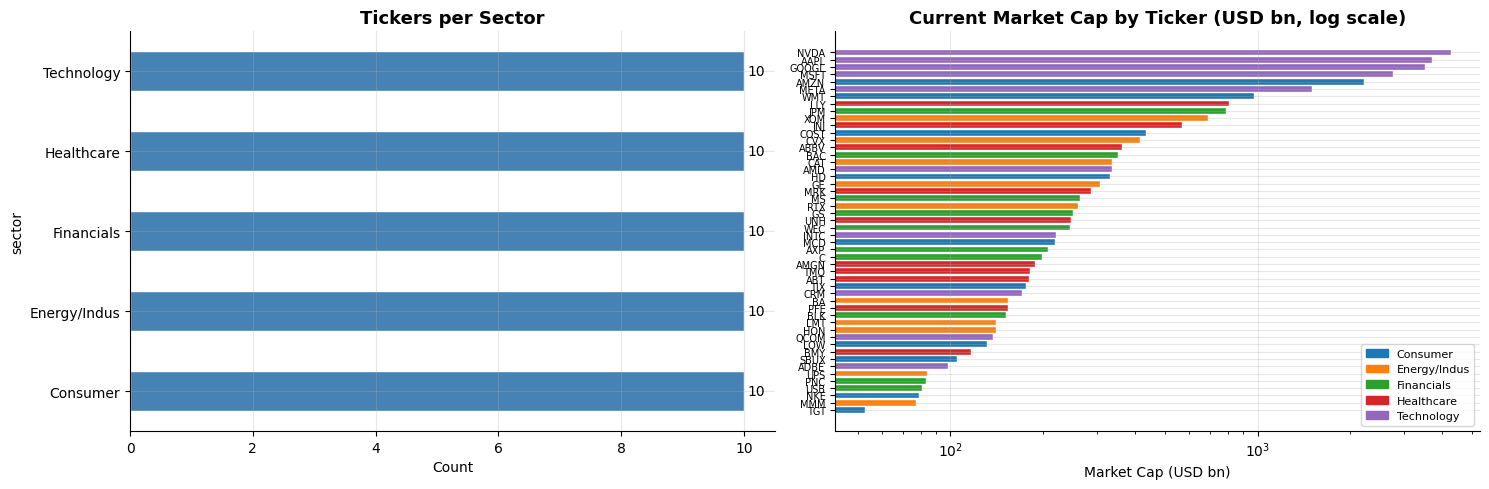

In [2]:
# 1a. Ticker overview: sector counts + market cap
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sector_counts = info.groupby('sector')['ticker'].count().sort_values()
sector_counts.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
for i, v in enumerate(sector_counts.values):
    axes[0].text(v + 0.05, i, str(v), va='center', fontsize=10)
axes[0].set_title('Tickers per Sector', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Count')

info_c = info.dropna(subset=['market_cap']).sort_values('market_cap')
bar_colors = [palette.get(s, 'gray') for s in info_c['sector']]
axes[1].barh(info_c['ticker'], info_c['market_cap'] / 1e9, color=bar_colors, edgecolor='white', linewidth=0.3)
axes[1].set_xscale('log')
axes[1].set_title('Current Market Cap by Ticker (USD bn, log scale)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Market Cap (USD bn)')
axes[1].tick_params(axis='y', labelsize=7)
legend_patches = [mpatches.Patch(color=c, label=s) for s, c in palette.items()]
axes[1].legend(handles=legend_patches, loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

In [3]:
# 1b. Full ticker list with sector and name
print(info[['ticker','sector','short_name','market_cap']]
      .sort_values(['sector','market_cap'], ascending=[True,False])
      .assign(market_cap_bn=lambda d: (d['market_cap']/1e9).round(1))
      .drop('market_cap', axis=1)
      .to_string(index=False))

ticker       sector                      short_name  market_cap_bn
  AMZN     Consumer                Amazon.com, Inc.         2224.7
   WMT     Consumer                    Walmart Inc.          973.0
  COST     Consumer    Costco Wholesale Corporation          432.2
    HD     Consumer          Home Depot, Inc. (The)          329.6
   MCD     Consumer          McDonald's Corporation          219.7
   TJX     Consumer       TJX Companies, Inc. (The)          176.3
   LOW     Consumer          Lowe's Companies, Inc.          131.5
  SBUX     Consumer           Starbucks Corporation          104.8
   NKE     Consumer                      Nike, Inc.           79.2
   TGT     Consumer              Target Corporation           52.5
   XOM Energy/Indus         Exxon Mobil Corporation          689.1
   CVX Energy/Indus             Chevron Corporation          413.4
   CAT Energy/Indus               Caterpillar, Inc.          335.4
    GE Energy/Indus                    GE Aerospace          3

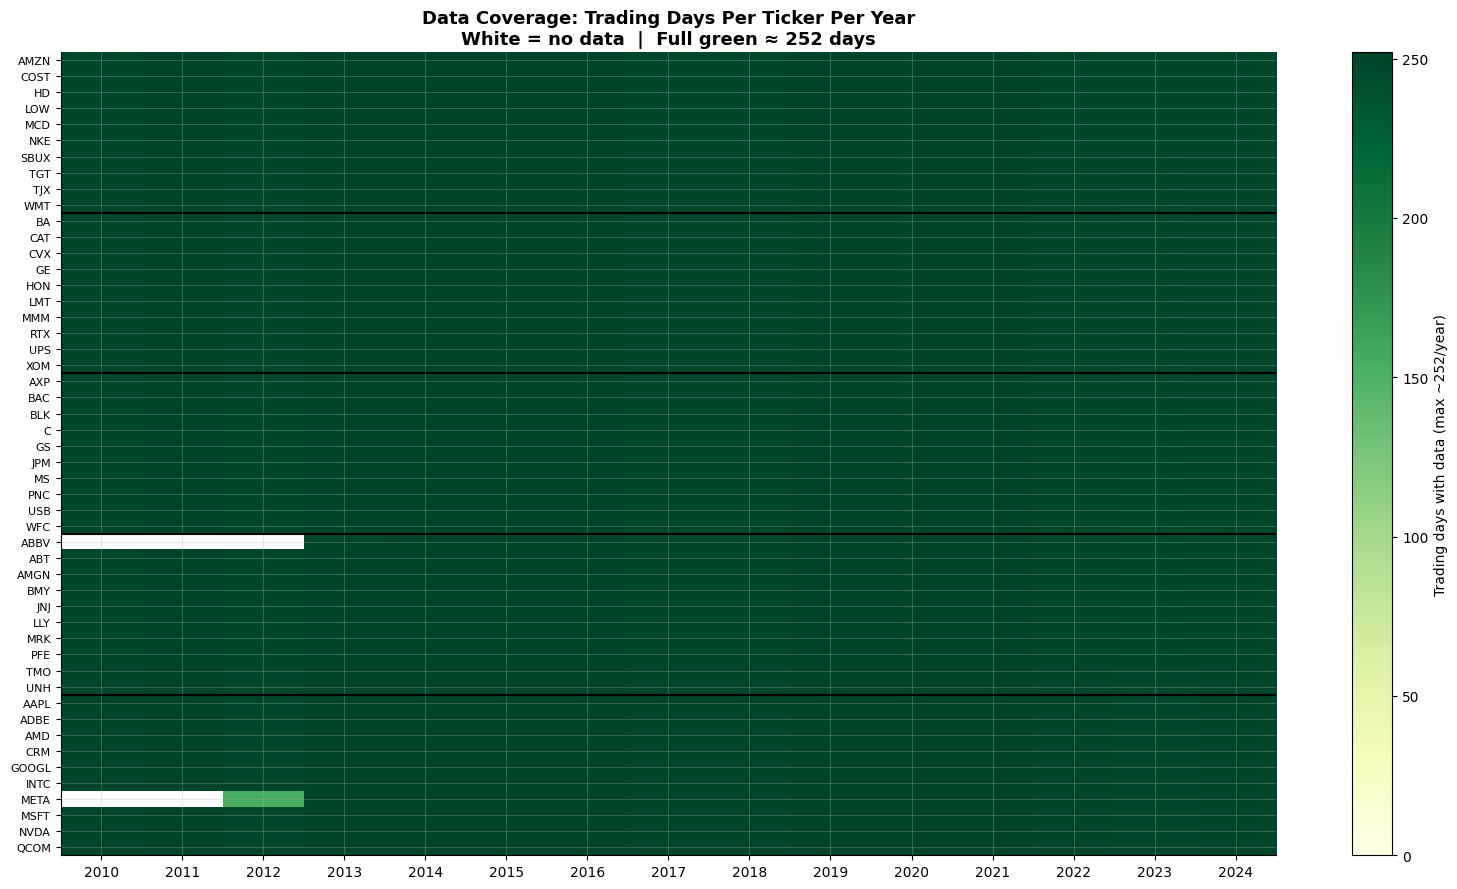

Tickers with partial history (listed after 2010):
  ABBV: first date 2013-01-03
  META: first date 2012-05-21


In [4]:
# 1c. Data coverage heatmap — which tickers have data in which years?
panel['year'] = panel['date'].dt.year
coverage = panel.groupby(['ticker','year'])['ret'].count().unstack('year')
to = [t for t in ticker_order if t in coverage.index]
coverage = coverage.loc[to]

fig, ax = plt.subplots(figsize=(16, 9))
im = ax.imshow(coverage.values, cmap='YlGn', aspect='auto', vmin=0, vmax=252)
ax.set_xticks(range(len(coverage.columns)))
ax.set_xticklabels(coverage.columns)
ax.set_yticks(range(len(coverage.index)))
ax.set_yticklabels(coverage.index, fontsize=8)
plt.colorbar(im, ax=ax, label='Trading days with data (max ~252/year)')

current = None
for i, t in enumerate(coverage.index):
    s = ticker_sector.get(t)
    if s != current and current is not None:
        ax.axhline(i - 0.5, color='black', linewidth=1.5)
    current = s

ax.set_title('Data Coverage: Trading Days Per Ticker Per Year\nWhite = no data  |  Full green ≈ 252 days', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Tickers with partial history (listed after 2010):')
partial = coverage[coverage.iloc[:,0].isna()].index.tolist()
for t in partial:
    first = panel[panel['ticker']==t]['date'].min().date()
    print(f'  {t}: first date {first}')

---
## Section 2: What Did the Market Look Like?
---

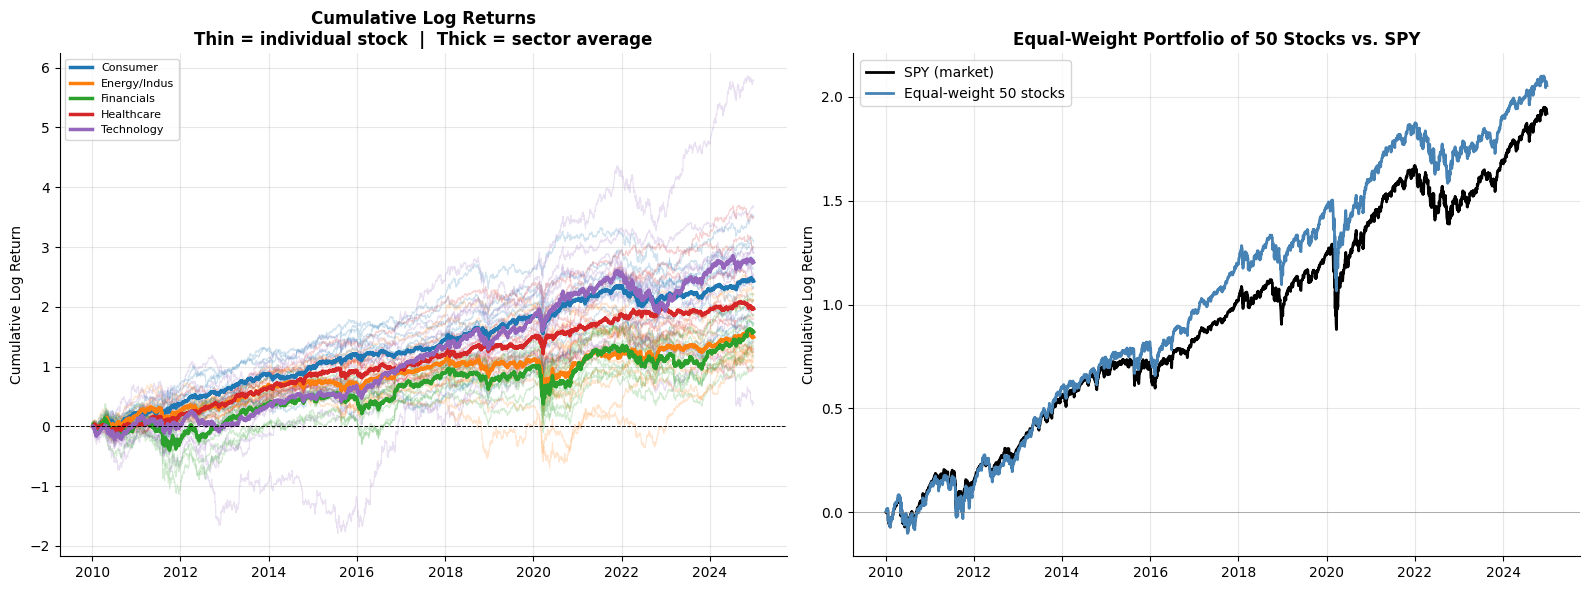

In [5]:
# 2a. Cumulative returns: individual stocks + sector averages + SPY
panel_s = panel.sort_values(['ticker','date']).copy()
panel_s['cum_ret'] = panel_s.groupby('ticker')['ret'].cumsum()
sector_cum = panel_s.groupby(['sector','date'])['cum_ret'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ticker, grp in panel_s.groupby('ticker'):
    s = ticker_sector.get(ticker,'Other')
    axes[0].plot(grp['date'], grp['cum_ret'], color=palette.get(s,'gray'), alpha=0.2, linewidth=0.8)
for s, grp in sector_cum.groupby('sector'):
    axes[0].plot(grp['date'], grp['cum_ret'], color=palette.get(s,'gray'), linewidth=2.5, label=s)
axes[0].axhline(0, color='black', linewidth=0.7, linestyle='--')
axes[0].set_title('Cumulative Log Returns\nThin = individual stock  |  Thick = sector average', fontweight='bold')
axes[0].set_ylabel('Cumulative Log Return')
axes[0].legend(fontsize=8, loc='upper left')

spy_cum = np.log(market['spy_close'] / market['spy_close'].iloc[0])
eq = panel_s.groupby('date')['ret'].mean().cumsum()
axes[1].plot(market['date'], spy_cum, 'k-', linewidth=2, label='SPY (market)')
axes[1].plot(eq.index, eq.values, color='steelblue', linewidth=2, label='Equal-weight 50 stocks')
axes[1].axhline(0, color='gray', linewidth=0.4)
axes[1].set_title('Equal-Weight Portfolio of 50 Stocks vs. SPY', fontweight='bold')
axes[1].set_ylabel('Cumulative Log Return')
axes[1].legend()

plt.tight_layout()
plt.show()

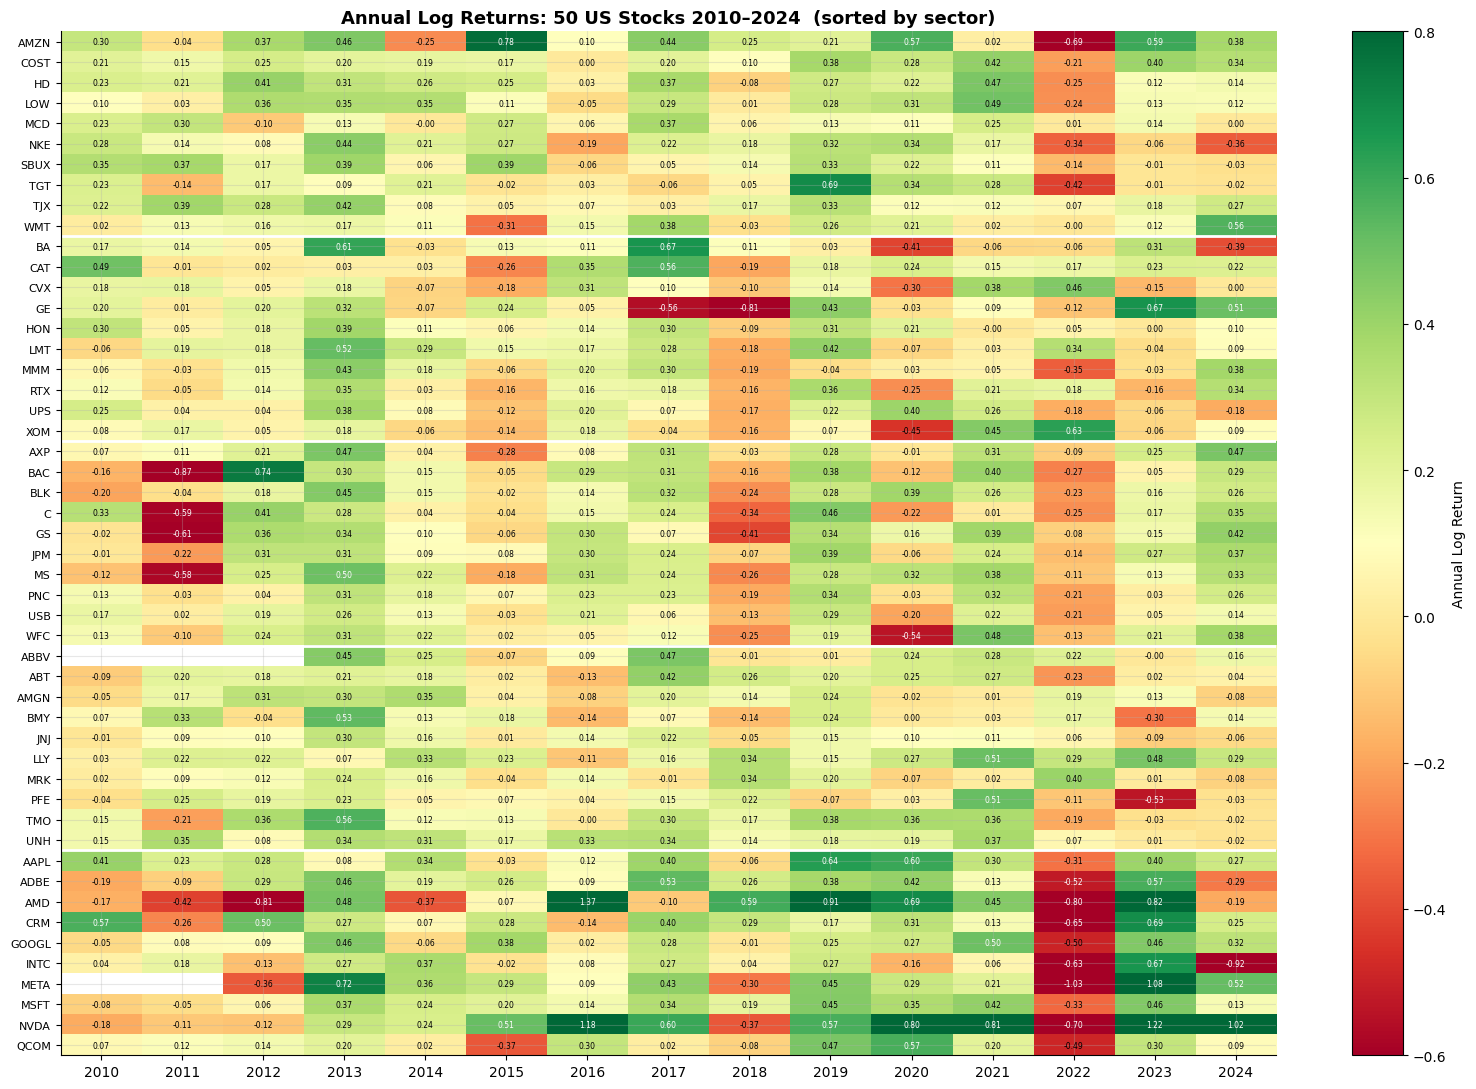

In [6]:
# 2b. Annual return heatmap
annual_ret = panel.groupby(['ticker','year'])['ret'].sum().unstack('year')
annual_ret = annual_ret.loc[[t for t in ticker_order if t in annual_ret.index]]

fig, ax = plt.subplots(figsize=(16, 11))
im = ax.imshow(annual_ret.values, cmap='RdYlGn', aspect='auto', vmin=-0.6, vmax=0.8)
ax.set_xticks(range(len(annual_ret.columns)))
ax.set_xticklabels(annual_ret.columns)
ax.set_yticks(range(len(annual_ret.index)))
ax.set_yticklabels(annual_ret.index, fontsize=8)
plt.colorbar(im, ax=ax, label='Annual Log Return')

for i in range(len(annual_ret.index)):
    for j in range(len(annual_ret.columns)):
        v = annual_ret.values[i,j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=5.5,
                    color='black' if abs(v) < 0.5 else 'white')

current = None
for i, t in enumerate(annual_ret.index):
    s = ticker_sector.get(t)
    if s != current and current is not None:
        ax.axhline(i-0.5, color='white', linewidth=2)
    current = s

ax.set_title('Annual Log Returns: 50 US Stocks 2010–2024  (sorted by sector)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

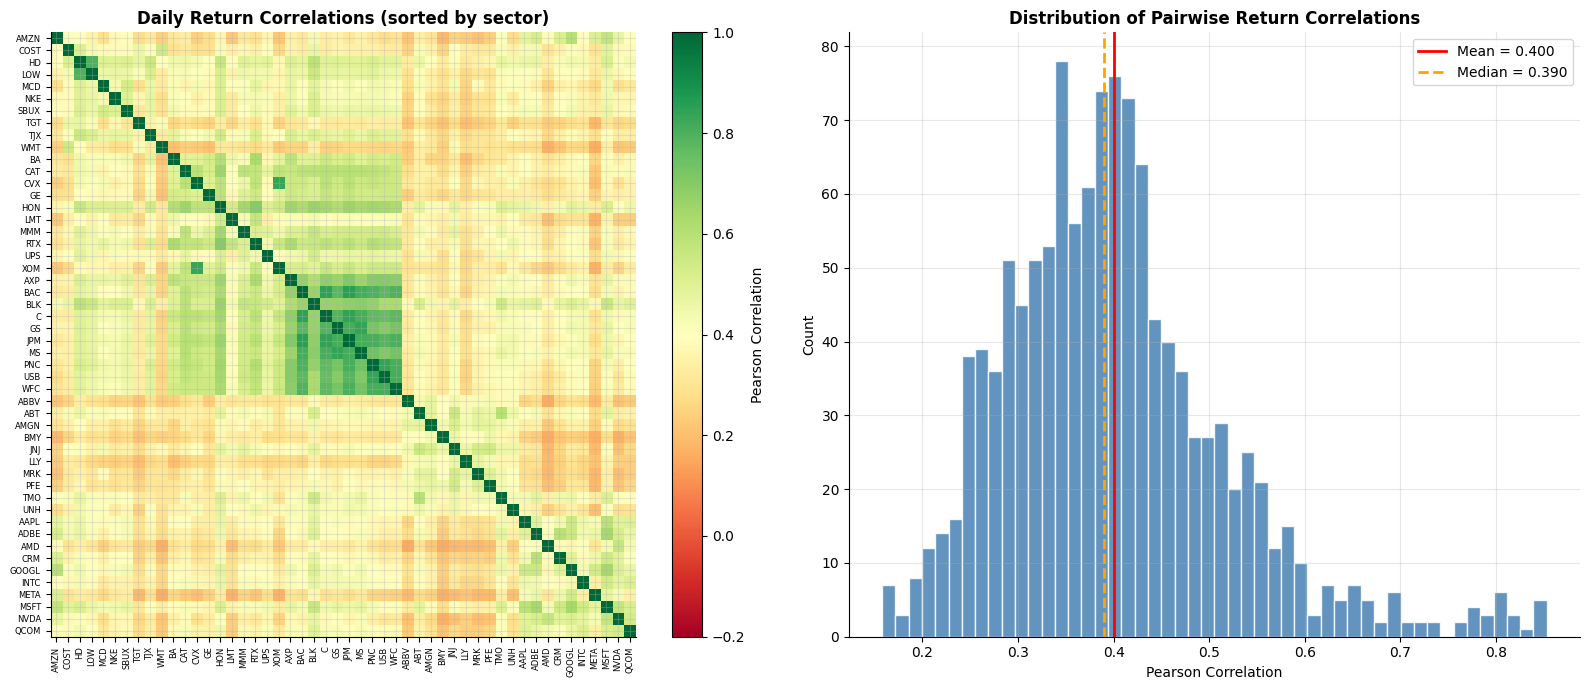

Average pairwise correlation : 0.400
This means stocks co-move ~40% on average — driven by the common market factor.
The remaining ~60% is idiosyncratic — where stock-specific features live.


In [7]:
# 2c. Return correlation heatmap
ret_wide = panel.pivot(index='date', columns='ticker', values='ret').dropna(how='all')
sorted_t = [t for t in ticker_order if t in ret_wide.columns]
corr = ret_wide[sorted_t].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
im = axes[0].imshow(corr.values, cmap='RdYlGn', vmin=-0.2, vmax=1.0, aspect='auto')
axes[0].set_xticks(range(len(sorted_t)))
axes[0].set_yticks(range(len(sorted_t)))
axes[0].set_xticklabels(sorted_t, rotation=90, fontsize=6)
axes[0].set_yticklabels(sorted_t, fontsize=6)
plt.colorbar(im, ax=axes[0], label='Pearson Correlation')
axes[0].set_title('Daily Return Correlations (sorted by sector)', fontweight='bold')

upper = corr.values[np.triu_indices_from(corr.values, k=1)]
axes[1].hist(upper, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(upper.mean(), color='red', linewidth=2, label=f'Mean = {upper.mean():.3f}')
axes[1].axvline(np.median(upper), color='orange', linewidth=2, linestyle='--', label=f'Median = {np.median(upper):.3f}')
axes[1].set_title('Distribution of Pairwise Return Correlations', fontweight='bold')
axes[1].set_xlabel('Pearson Correlation')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Average pairwise correlation : {upper.mean():.3f}')
print(f'This means stocks co-move ~{upper.mean()*100:.0f}% on average — driven by the common market factor.')
print(f'The remaining ~{(1-upper.mean())*100:.0f}% is idiosyncratic — where stock-specific features live.')

---
## Section 3: What Was the Macro Environment?

Each of these four series will be used as a **feature** in later notebooks.

| Variable | Column | Why it matters |
|---|---|---|
| SPY | `spy_close`, `market_ret` | The market return — the most important common driver |
| VIX | `vix` | Fear index — high VIX = risk-off, stocks under pressure |
| Yield spread (10y−3m) | `yield_spread` | Inverted yield curve has historically predicted recessions |
| USD index | `usd_index` | Strong dollar often hurts large-cap multinationals |

---

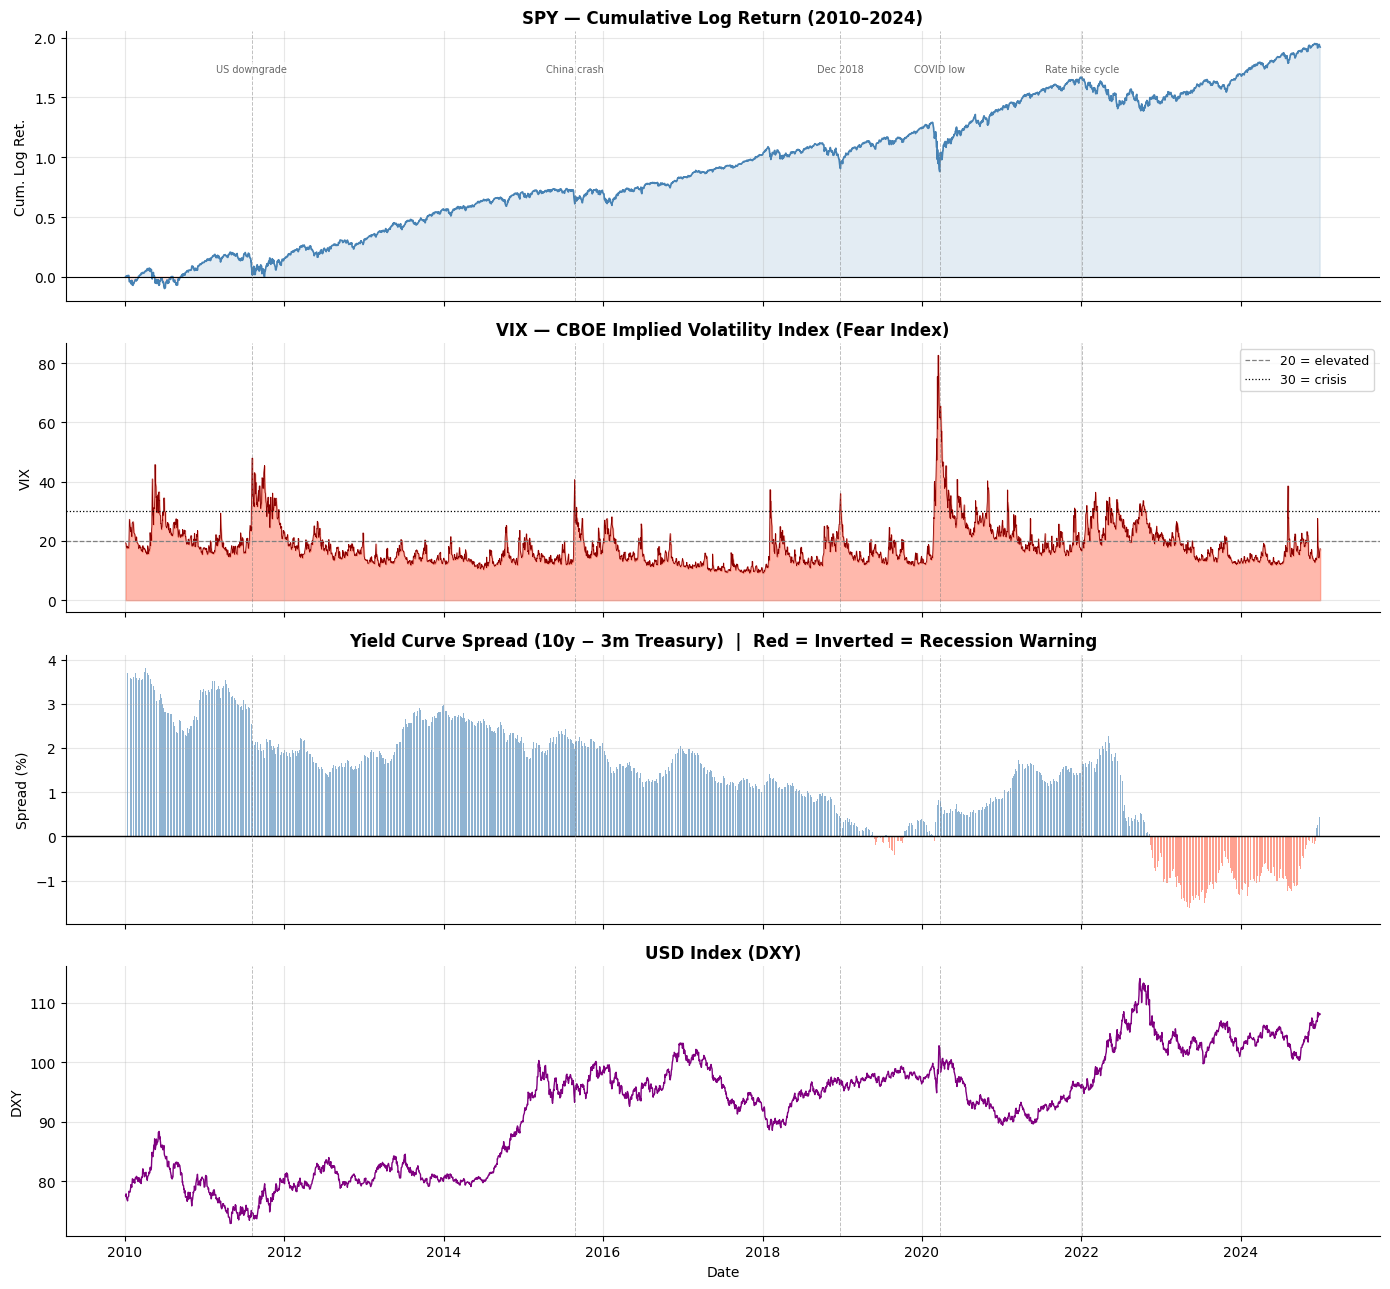

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(14, 13), sharex=True)

# SPY
spy_cum = np.log(market['spy_close'] / market['spy_close'].iloc[0])
axes[0].plot(market['date'], spy_cum, color='steelblue', linewidth=1.2)
axes[0].fill_between(market['date'], spy_cum, 0, where=spy_cum >= 0, alpha=0.15, color='steelblue')
axes[0].fill_between(market['date'], spy_cum, 0, where=spy_cum < 0,  alpha=0.15, color='tomato')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('SPY — Cumulative Log Return (2010–2024)', fontweight='bold')
axes[0].set_ylabel('Cum. Log Ret.')

# VIX
axes[1].fill_between(market['date'], market['vix'], alpha=0.45, color='tomato')
axes[1].plot(market['date'], market['vix'], color='darkred', linewidth=0.6)
axes[1].axhline(20, color='gray', linewidth=0.9, linestyle='--', label='20 = elevated')
axes[1].axhline(30, color='black', linewidth=0.9, linestyle=':', label='30 = crisis')
axes[1].set_title('VIX — CBOE Implied Volatility Index (Fear Index)', fontweight='bold')
axes[1].set_ylabel('VIX')
axes[1].legend(fontsize=9)

# Yield spread
spread = market['yield_spread']
axes[2].bar(market['date'], spread,
            color=np.where(spread < 0, 'tomato', 'steelblue'), alpha=0.6, width=1)
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set_title('Yield Curve Spread (10y − 3m Treasury)  |  Red = Inverted = Recession Warning', fontweight='bold')
axes[2].set_ylabel('Spread (%)')

# USD index
axes[3].plot(market['date'], market['usd_index'], color='purple', linewidth=1)
axes[3].set_title('USD Index (DXY)', fontweight='bold')
axes[3].set_ylabel('DXY')
axes[3].set_xlabel('Date')

# Annotate key events
events = {
    '2011-08-05': 'US downgrade',
    '2015-08-24': 'China crash',
    '2018-12-24': 'Dec 2018',
    '2020-03-23': 'COVID low',
    '2022-01-03': 'Rate hike cycle',
}
for d_str, lbl in events.items():
    d = pd.Timestamp(d_str)
    for ax in axes:
        ax.axvline(d, color='gray', linewidth=0.7, linestyle='--', alpha=0.5)
    axes[0].text(d, spy_cum.max() * 0.88, lbl, fontsize=7, ha='center', color='dimgray',
                 rotation=0, bbox=dict(fc='white', ec='none', alpha=0.6, pad=1))

plt.tight_layout()
plt.show()

In [9]:
# Summary statistics for macro variables
print('=== Macro Variable Summary Statistics ===')
macro_summary = market[['market_ret','vix','yield_10y','yield_3m','yield_spread','usd_index']].describe().round(4)
print(macro_summary)

=== Macro Variable Summary Statistics ===
       market_ret        vix  yield_10y   yield_3m  yield_spread  usd_index
count   3771.0000  3771.0000  3771.0000  3771.0000     3771.0000  3771.0000
mean       0.0005    18.3744     2.4917     1.1921        1.2997    92.1957
std        0.0108     6.9645     0.9336     1.7196        1.2316     9.3859
min       -0.1159     9.1400     0.4990    -0.1050       -1.7040    72.9300
25%       -0.0037    13.6000     1.8235     0.0450        0.5150    82.1500
50%        0.0007    16.5900     2.3760     0.1500        1.5040    94.5000
75%        0.0058    21.1600     3.0025     1.8800        2.1220    98.7250
max        0.0867    82.6900     4.9880     5.3480        3.8340   114.1100


---
## Section 4: How Much Does the Market Explain Each Stock?

For any stock, its daily return can be decomposed as:
$$r_t = \alpha + \beta \cdot r_t^{\text{market}} + \varepsilon_t$$

- **Beta**: sensitivity to the market
- **R²**: fraction of daily variance explained by the market
- **Alpha**: average return unexplained by the market (annualized)

The **residual** $\varepsilon_t$ is the stock-specific component — that is where stock-level features matter.

---

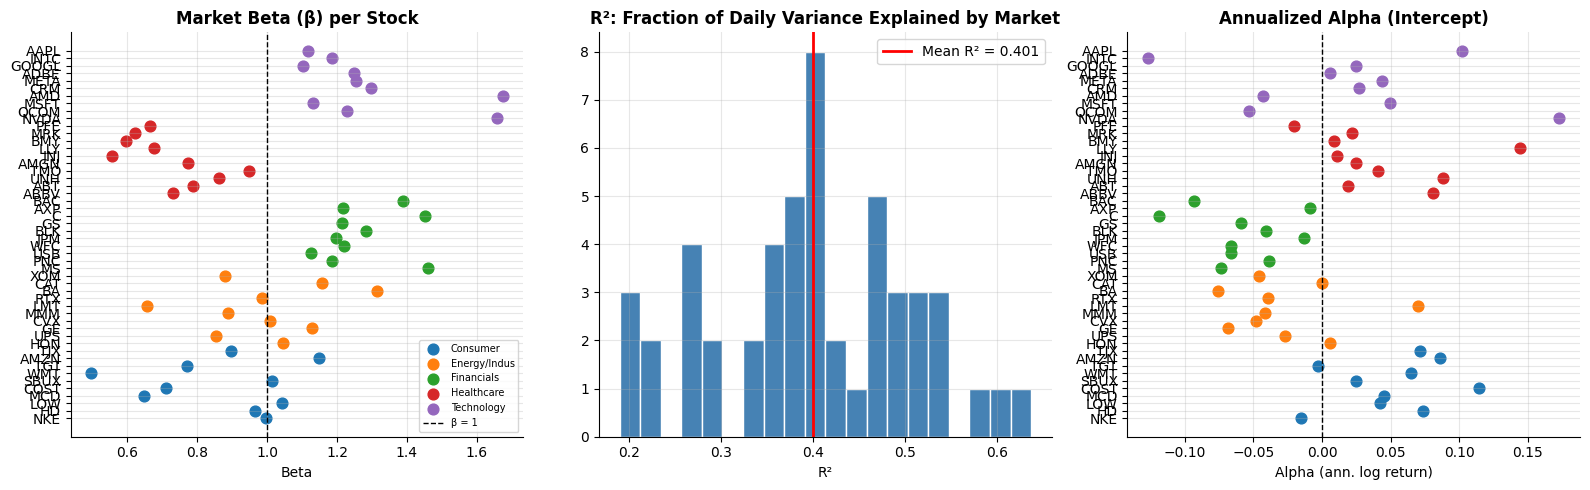

Average R²   : 0.401  — market explains 40% of daily variance
Average beta : 1.029
Residual     : ~60% of variance is idiosyncratic — this is where feature engineering adds value


In [10]:
panel_m = panel.merge(market[['date','market_ret']], on='date', how='left')

beta_rows = []
for ticker, grp in panel_m.groupby('ticker'):
    valid = grp[['ret','market_ret']].dropna()
    if len(valid) < 100:
        continue
    slope, intercept, r_val, pval, _ = stats.linregress(valid['market_ret'], valid['ret'])
    beta_rows.append({'ticker': ticker, 'sector': ticker_sector.get(ticker),
                      'beta': slope, 'alpha_ann': intercept*252, 'r2': r_val**2, 'n': len(valid)})

betas = pd.DataFrame(beta_rows).sort_values('sector')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for s, grp in betas.groupby('sector'):
    axes[0].scatter(grp['beta'], grp['ticker'], color=palette.get(s), s=60, label=s)
axes[0].axvline(1.0, color='black', linewidth=1, linestyle='--', label='β = 1')
axes[0].set_title('Market Beta (β) per Stock', fontweight='bold')
axes[0].set_xlabel('Beta')
axes[0].legend(fontsize=7)

axes[1].hist(betas['r2'], bins=20, color='steelblue', edgecolor='white')
axes[1].axvline(betas['r2'].mean(), color='red', linewidth=2,
                label=f'Mean R² = {betas["r2"].mean():.3f}')
axes[1].set_title('R²: Fraction of Daily Variance Explained by Market', fontweight='bold')
axes[1].set_xlabel('R²')
axes[1].legend()

for s, grp in betas.groupby('sector'):
    axes[2].scatter(grp['alpha_ann'], grp['ticker'], color=palette.get(s), s=60)
axes[2].axvline(0, color='black', linewidth=1, linestyle='--')
axes[2].set_title('Annualized Alpha (Intercept)', fontweight='bold')
axes[2].set_xlabel('Alpha (ann. log return)')

plt.tight_layout()
plt.show()

print(f'Average R²   : {betas["r2"].mean():.3f}  — market explains {betas["r2"].mean()*100:.0f}% of daily variance')
print(f'Average beta : {betas["beta"].mean():.3f}')
print(f'Residual     : ~{(1-betas["r2"].mean())*100:.0f}% of variance is idiosyncratic — this is where feature engineering adds value')

In [11]:
# Beta table
print('=== Beta Table (sorted by sector, then beta) ===')
print(betas.sort_values(['sector','beta'])
          [['ticker','sector','beta','r2','alpha_ann']]
          .rename(columns={'alpha_ann':'alpha (ann.)'})
          .round(4)
          .to_string(index=False))

=== Beta Table (sorted by sector, then beta) ===
ticker       sector   beta     r2  alpha (ann.)
   WMT     Consumer 0.4969 0.1962        0.0648
   MCD     Consumer 0.6478 0.3561        0.0453
  COST     Consumer 0.7098 0.3599        0.1147
   TGT     Consumer 0.7703 0.2115       -0.0032
   TJX     Consumer 0.8967 0.3786        0.0712
    HD     Consumer 0.9659 0.5004        0.0739
   NKE     Consumer 0.9967 0.3722       -0.0149
  SBUX     Consumer 1.0131 0.3997        0.0248
   LOW     Consumer 1.0425 0.4133        0.0420
  AMZN     Consumer 1.1480 0.3615        0.0859
   LMT Energy/Indus 0.6570 0.2886        0.0700
   UPS Energy/Indus 0.8550 0.3932       -0.0272
   XOM Energy/Indus 0.8808 0.3642       -0.0459
   MMM Energy/Indus 0.8867 0.4283       -0.0414
   RTX Energy/Indus 0.9860 0.4606       -0.0396
   CVX Energy/Indus 1.0073 0.4100       -0.0482
   HON Energy/Indus 1.0459 0.6125        0.0061
    GE Energy/Indus 1.1277 0.3769       -0.0688
   CAT Energy/Indus 1.1575 0.4632      

---
## Summary

We now know our dataset well:

| What we have | Detail |
|---|---|
| **50 large-cap US stocks** | 5 sectors, 10 per sector, 2010–2024 |
| **187k rows** in panel | Daily OHLCV + log return + sector label |
| **3,771 rows** in market | SPY, VIX, yield curve, USD index |
| **Beta range** | ~0.4 (JNJ) to ~1.8 (NVDA) |
| **Market R²** | ~30–70% of daily variance explained by SPY |
| **Remaining** | ~40–70% of each stock's variance is idiosyncratic |

---

### Next
**Part 2** — We zoom in on a single stock (AAPL) and try to predict its next-day return using:
- Its own historical price features (momentum, volatility)
- Macro features (SPY return, VIX, yield spread)
- Fundamental data discussion (PE, PB — what's available for free and what's not)

---

### Exercises
1. Which sector has the highest average beta? Which has the lowest?
2. In the correlation heatmap, do stocks within the same sector cluster together? What does this mean?
3. Look at the yield curve inversion periods. When did the spread go negative? What happened to SPY afterwards?
4. NVDA has one of the highest betas. Find its row in the annual return heatmap. How does a high-beta stock behave during market downturns (2022) vs. bull markets (2023)?